In [25]:
from pathlib import Path
import os
import json
import base64
import time
import re

import pandas as pd
from tqdm.notebook import tqdm
from dotenv import load_dotenv
from groq import Groq

PROJECT_ROOT = Path("/Users/yongyili/urban-emotional-intelligence")
DATA_DIR = PROJECT_ROOT / "data"
IMAGE_DIR = PROJECT_ROOT / "images"

load_dotenv(PROJECT_ROOT / ".env")

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found. Check your .env file.")

client = Groq(api_key=GROQ_API_KEY)

print("Project root:", PROJECT_ROOT)
print("Groq key loaded:", GROQ_API_KEY is not None)

Project root: /Users/yongyili/urban-emotional-intelligence
Groq key loaded: True


In [27]:
manifest_path = DATA_DIR / "image_manifest.parquet"

if not manifest_path.exists():
    raise FileNotFoundError("data/image_manifest.parquet not found. Stage 1 output missing.")

manifest = pd.read_parquet(manifest_path)

print("Manifest shape:", manifest.shape)
manifest.head()

Manifest shape: (655, 11)


,image_id,filepath,borough,road_type,sample_latitude,sample_longitude,latitude,longitude,compass_angle,captured_at,source
0,2567577653535954,images/Kingston_upon_Thames/2567577653535954.jpg,Kingston upon Thames,unknown,51.351090,-0.305450,51.351651,-0.312890,13.042664,1499686461379,Mapillary
1,227868632440032,images/Kingston_upon_Thames/227868632440032.jpg,Kingston upon Thames,unknown,51.401414,-0.262992,51.403125,-0.261115,277.307770,1414503548000,Mapillary
2,1101120203722336,images/Kingston_upon_Thames/1101120203722336.jpg,Kingston upon Thames,unknown,51.348385,-0.328315,51.351438,-0.330623,58.696777,1545651013361,Mapillary
3,220316326204880,images/Kingston_upon_Thames/220316326204880.jpg,Kingston upon Thames,unknown,51.386792,-0.270959,51.387736,-0.271491,44.678802,1612180724046,Mapillary
4,160502959355506,images/Kingston_upon_Thames/160502959355506.jpg,Kingston upon Thames,unknown,51.391711,-0.310473,51.392385,-0.310321,213.639465,1606489867752,Mapillary


In [28]:
missing_files = []

for fp in manifest["filepath"]:
    if not (PROJECT_ROOT / fp).exists():
        missing_files.append(fp)

print("Missing image files:", len(missing_files))

Missing image files: 0


In [29]:
SYSTEM_PROMPT = """
You are an urban environmental analyst.
Extract structured visual features from London street photographs.
Do not interpret emotions.
Only report observable visual features.
Return valid JSON only.
"""

USER_PROMPT = """
Examine this London street photograph carefully.

Report ONLY what you can observe directly. Be precise.
Do not infer emotions or feelings.
Do not include markdown.
Respond ONLY with this JSON object and nothing else:

{
  "scene_description": "one paragraph objective description of the visible street scene",
  "sky_fraction": <float 0.0 to 1.0>,
  "greenery_present": <true or false>,
  "greenery_density": <"none", "low", "medium", or "high">,
  "building_height_ratio": <"low", "medium", or "high">,
  "traffic_intensity": <"none", "light", "moderate", or "heavy">,
  "pedestrian_activity": <"none", "low", "medium", or "high">,
  "surface_condition": <"poor", "fair", "good", or "excellent">,
  "lighting": <"dark", "dim", "normal", or "bright">
}"""

In [30]:
def encode_image_to_base64(image_path):
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

In [31]:
VALID_VALUES = {
    "greenery_density": {"none", "low", "medium", "high"},
    "building_height_ratio": {"low", "medium", "high"},
    "traffic_intensity": {"none", "light", "moderate", "heavy"},
    "pedestrian_activity": {"none", "low", "medium", "high"},
    "surface_condition": {"poor", "fair", "good", "excellent"},
    "lighting": {"dark", "dim", "normal", "bright"},
}

REQUIRED_FEATURE_KEYS = [
    "scene_description",
    "sky_fraction",
    "greenery_present",
    "greenery_density",
    "building_height_ratio",
    "traffic_intensity",
    "pedestrian_activity",
    "surface_condition",
    "lighting",
]


def extract_json_from_text(text):
    """
    Parse JSON from model output.
    Handles clean JSON and simple ```json ... ``` wrappers.
    """
    if text is None:
        raise ValueError("Empty model response")
    
    text = text.strip()
    
    # Remove Markdown code fences if present
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)
    
    # If extra text appears, extract first JSON object
    start = text.find("{")
    end = text.rfind("}")
    
    if start == -1 or end == -1:
        raise ValueError(f"No JSON object found in response: {text[:200]}")
    
    text = text[start:end+1]
    return json.loads(text)


def validate_and_clean_features(features):
    """
    Validate required keys and normalise values.
    """
    cleaned = {}
    
    for key, allowed in VALID_VALUES.items():
        value = str(features[key]).strip().lower()

    # Accept reasonable model variants and map them to our schema
        if key == "building_height_ratio" and value in {"none", "no buildings", "not visible"}:
            value = "low"

        if key == "traffic_intensity" and value in {"low"}:
            value = "light"

        if key == "surface_condition" and value in {"none", "not visible", "unclear", "unknown", "n/a"}:
            value = "fair"

        if key == "lighting" and value in {"daylight"}:
            value = "normal"

        if value not in allowed:
            raise ValueError(f"Invalid value for {key}: {value}")

        cleaned[key] = value
    
    return cleaned

In [32]:
MODEL_NAME = "meta-llama/llama-4-scout-17b-16e-instruct"


def extract_features_from_image(image_path, model=MODEL_NAME, max_retries=3):
    image_path = Path(image_path)
    b64 = encode_image_to_base64(image_path)

    last_error = None

    for attempt in range(max_retries + 1):
        try:
            response = client.chat.completions.create(
                model=model,
                max_tokens=250,
                temperature=0,
                response_format={"type": "json_object"},
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {
                        "role": "user",
                        "content": [
                            {"type": "text", "text": USER_PROMPT},
                            {
                                "type": "image_url",
                                "image_url": {
                                    "url": f"data:image/jpeg;base64,{b64}"
                                }
                            }
                        ]
                    }
                ]
            )

            raw_text = response.choices[0].message.content
            parsed = extract_json_from_text(raw_text)
            cleaned = validate_and_clean_features(parsed)

            return cleaned, raw_text, None

        except Exception as e:
            last_error = str(e)
            lower_error = last_error.lower()

            if "tokens per day" in lower_error or "tpd" in lower_error:
                # Do not keep retrying heavily when daily token budget is exhausted.
                return None, None, last_error

            elif "rate limit" in lower_error or "429" in lower_error or "too many requests" in lower_error:
                wait_time = 60 * (attempt + 1)
                print(f"Rate limit detected. Waiting {wait_time}s...")
                time.sleep(wait_time)

            elif "invalid api key" in lower_error or "401" in lower_error:
                raise RuntimeError("Invalid Groq API key. Check GROQ_API_KEY in .env.")

            else:
                wait_time = 5 * (attempt + 1)
                time.sleep(wait_time)

    return None, None, last_error

In [35]:
test_row = manifest.iloc[0]
test_image_path = PROJECT_ROOT / test_row["filepath"]

print("Testing image:", test_image_path)

features, raw_text, error = extract_features_from_image(test_image_path)

print("Error:", error)
features

Testing image: /Users/yongyili/urban-emotional-intelligence/images/Kingston_upon_Thames/2567577653535954.jpg
Error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `meta-llama/llama-4-scout-17b-16e-instruct` in organization `org_01kqd7sheyeswvbd07bw01j9vj` service tier `on_demand` on tokens per day (TPD): Limit 500000, Used 499394, Requested 2788. Please try again in 6m17.0496s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


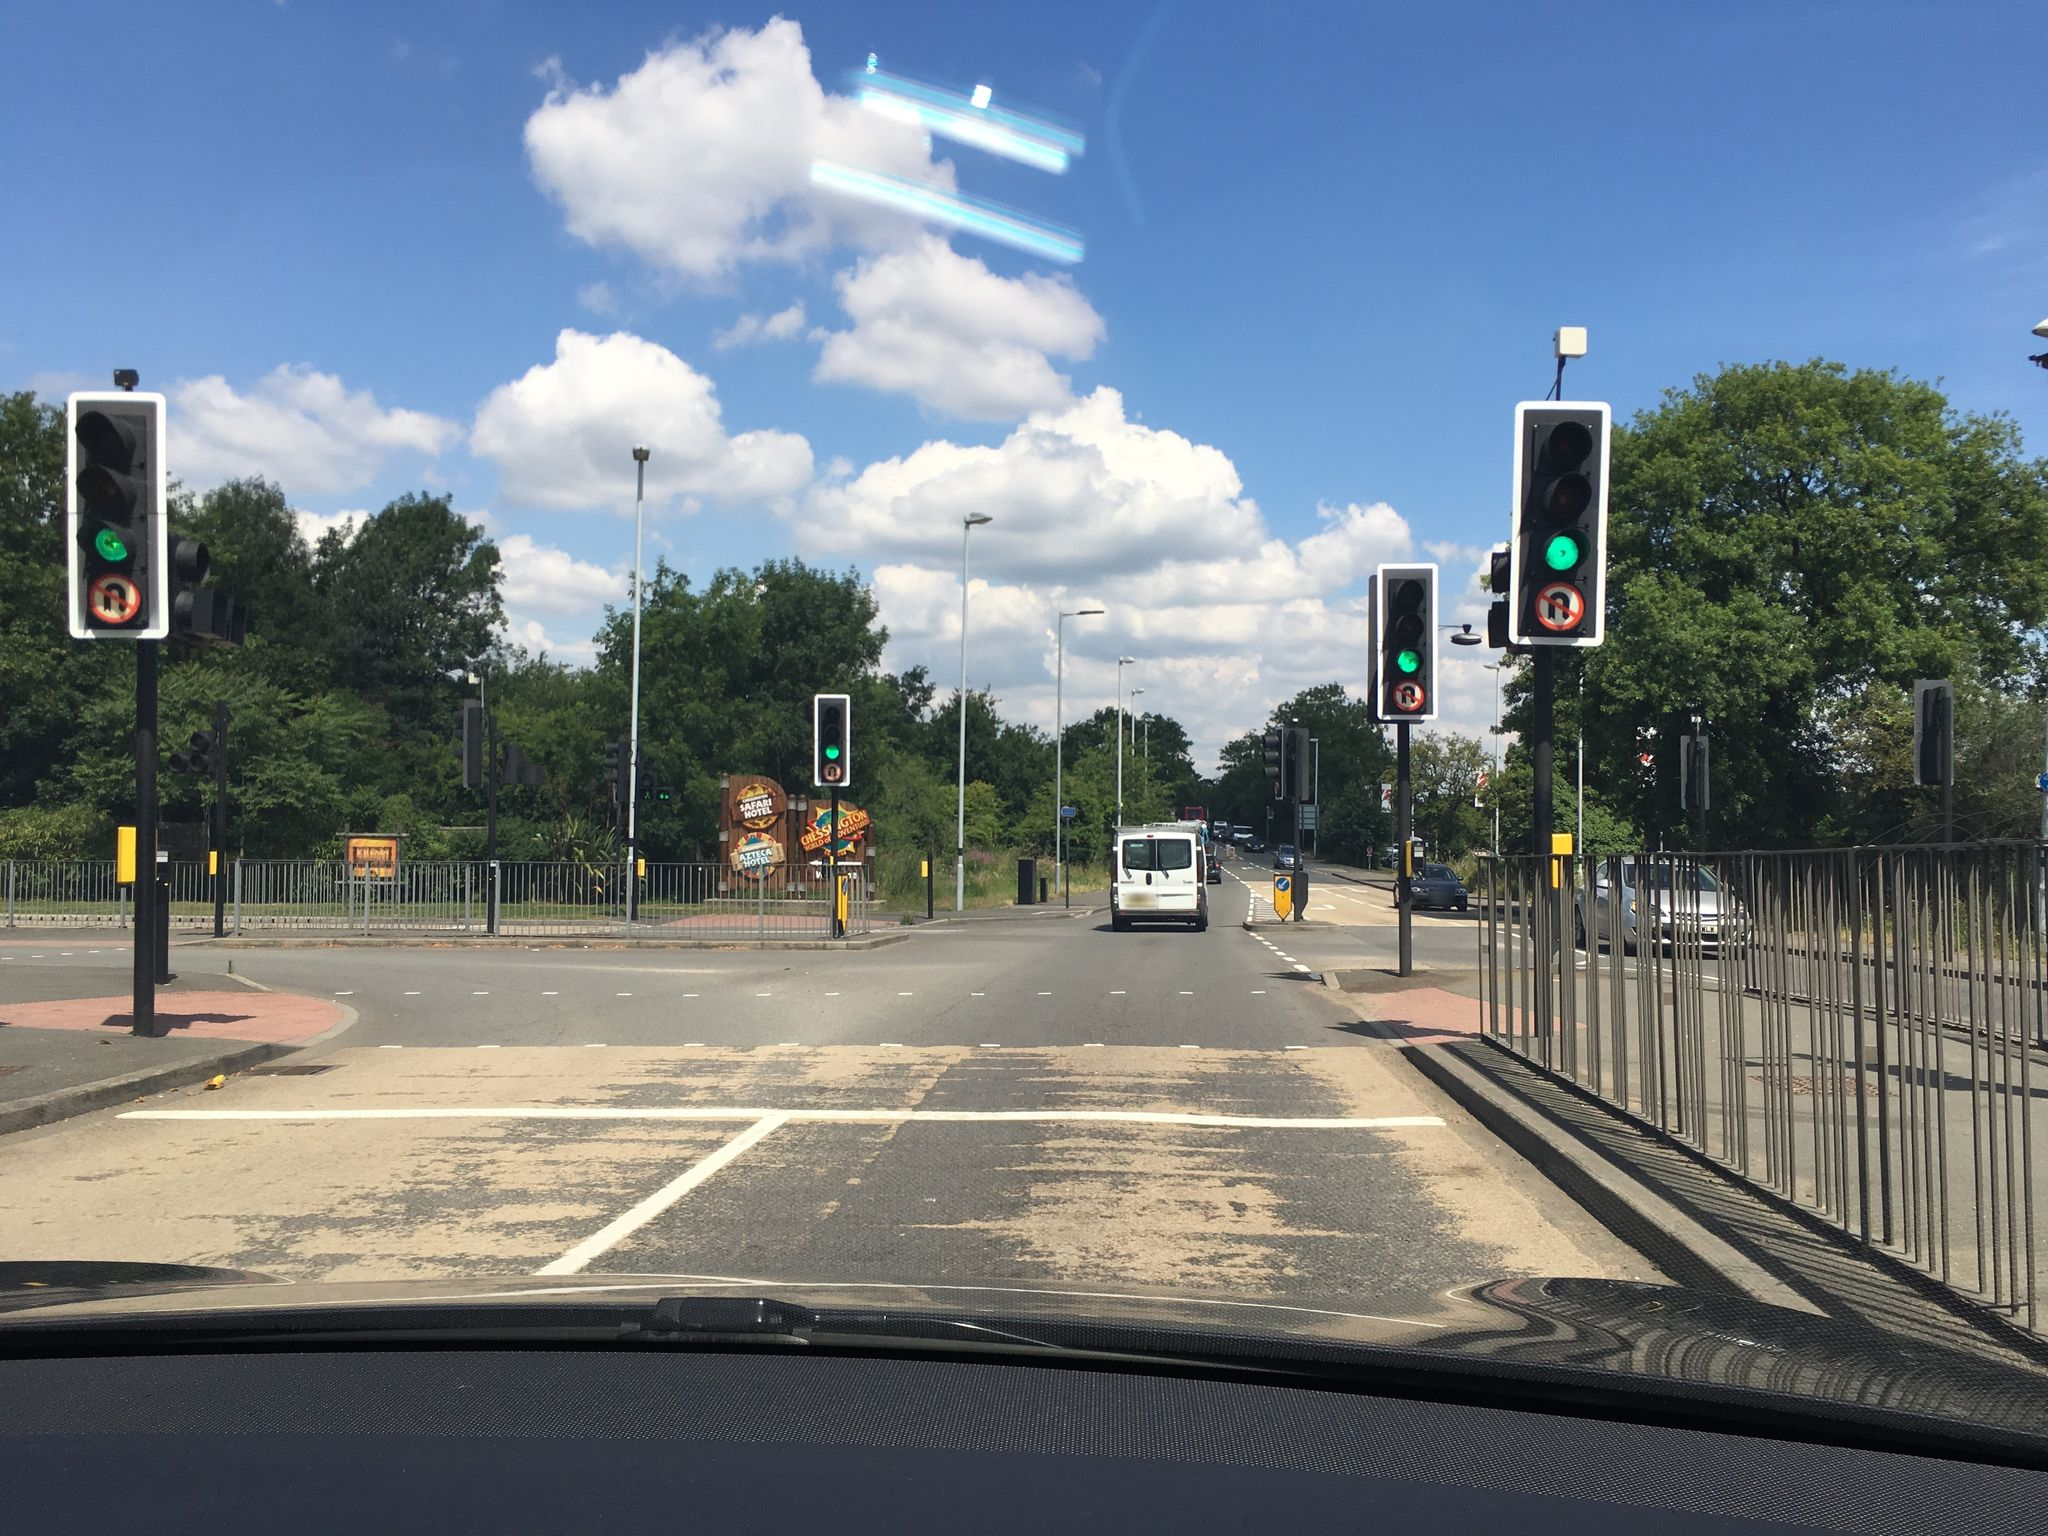

{'scene_description': 'A road intersection with traffic lights on both sides, a white van driving away from the camera in the center of the road, and trees lining the background under a blue sky with clouds.',
 'sky_fraction': 0.6,
 'greenery_present': True,
 'greenery_density': 'medium',
 'building_height_ratio': 'low',
 'traffic_intensity': 'light',
 'pedestrian_activity': 'none',
 'surface_condition': 'fair',
 'lighting': 'bright'}

In [18]:
from IPython.display import Image, display

display(Image(filename=str(test_image_path), width=500))
features

In [48]:
pilot_manifest = manifest.sample(n=10, random_state=42).copy()

pilot_results = []
pilot_errors = []

for _, row in tqdm(pilot_manifest.iterrows(), total=len(pilot_manifest)):
    image_path = PROJECT_ROOT / row["filepath"]

    features, raw_text, error = extract_features_from_image(image_path)

    if error:
        pilot_errors.append({
            "image_id": row["image_id"],
            "filepath": row["filepath"],
            "error": error
        })
    else:
        record = row.to_dict()
        record.update(features)
        pilot_results.append(record)

pilot_features_df = pd.DataFrame(pilot_results)
pilot_errors_df = pd.DataFrame(pilot_errors)

print("Pilot success:", len(pilot_features_df))
print("Pilot errors:", len(pilot_errors_df))

pilot_features_df.head()

  0%|          | 0/10 [00:00<?, ?it/s]

Pilot success: 10
Pilot errors: 0


,image_id,filepath,borough,road_type,sample_latitude,sample_longitude,latitude,longitude,compass_angle,captured_at,source,greenery_density,building_height_ratio,traffic_intensity,pedestrian_activity,surface_condition,lighting
0,294843682268377,images/Redbridge/294843682268377.jpg,Redbridge,unknown,51.590466,0.126247,51.584246,0.127868,274.262100,1494331220860,Mapillary,low,low,none,none,fair,normal
1,992729274465542,images/Ealing/992729274465542.jpg,Ealing,unknown,51.540264,-0.325643,51.542231,-0.327440,263.957520,1524042300000,Mapillary,medium,low,none,none,fair,bright
2,1786985018411895,images/Camden/1786985018411895.jpg,Camden,unknown,51.528779,-0.125335,51.528696,-0.124436,355.329793,1707048497781,Mapillary,low,medium,light,medium,good,normal
3,322291159395298,images/Bexley/322291159395298.jpg,Bexley,unknown,51.475070,0.155354,51.471443,0.154689,167.526012,1618417018000,Mapillary,low,low,light,none,fair,bright
4,266023545929762,images/Richmond_upon_Thames/266023545929762.jpg,Richmond upon Thames,unknown,51.450709,-0.368639,51.451047,-0.367797,194.246478,1685090309457,Mapillary,high,medium,none,none,poor,normal


In [20]:
pilot_features_df.to_csv(DATA_DIR / "pilot_vlm_features_groq.csv", index=False)
pilot_errors_df.to_csv(DATA_DIR / "pilot_vlm_feature_errors_groq.csv", index=False)

In [21]:
for col in [
    "greenery_density",
    "building_height_ratio",
    "traffic_intensity",
    "pedestrian_activity",
    "surface_condition",
    "lighting"
]:
    print("\n" + col)
    print(pilot_features_df[col].value_counts(dropna=False))


greenery_density
greenery_density
low       4
medium    4
high      1
none      1
Name: count, dtype: int64

building_height_ratio
building_height_ratio
low       6
medium    3
high      1
Name: count, dtype: int64

traffic_intensity
traffic_intensity
none        4
light       4
moderate    2
Name: count, dtype: int64

pedestrian_activity
pedestrian_activity
none      8
medium    1
low       1
Name: count, dtype: int64

surface_condition
surface_condition
fair    5
good    4
poor    1
Name: count, dtype: int64

lighting
lighting
normal    6
bright    2
dim       2
Name: count, dtype: int64


In [24]:
invalid_counts = {}

for col, allowed in VALID_VALUES.items():
    invalid = set(pilot_features_df[col].dropna().unique()) - allowed
    invalid_counts[col] = invalid

invalid_counts

{'greenery_density': set(),
 'building_height_ratio': set(),
 'traffic_intensity': set(),
 'pedestrian_activity': set(),
 'surface_condition': set(),
 'lighting': set()}

In [33]:
def clean_vlm_dataframe_for_saving(df):
    """
    Clean column types so CSV and Parquet saving works reliably.
    Especially important because image_id can become mixed int/string after resume.
    """
    df = df.copy()

    # Force IDs and paths to string
    string_cols = [
        "image_id",
        "filepath",
        "borough",
        "road_type",
        "source",
        "scene_description",
        "greenery_density",
        "building_height_ratio",
        "traffic_intensity",
        "pedestrian_activity",
        "surface_condition",
        "lighting"
    ]

    for col in string_cols:
        if col in df.columns:
            df[col] = df[col].astype("string")

    # Force booleans
    if "greenery_present" in df.columns:
        df["greenery_present"] = df["greenery_present"].astype(bool)

    # Force numeric columns
    numeric_cols = [
        "sky_fraction",
        "sample_latitude",
        "sample_longitude",
        "latitude",
        "longitude",
        "compass_angle",
        "captured_at"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

In [34]:
features_output_path = DATA_DIR / "vlm_features.parquet"
features_csv_path = DATA_DIR / "vlm_features.csv"
errors_output_path = DATA_DIR / "vlm_feature_errors.csv"
progress_csv_path = DATA_DIR / "vlm_features_progress.csv"


def run_vlm_feature_extraction(manifest, save_every=25, model=MODEL_NAME, sleep_seconds=0.5, max_consecutive_errors=10):
    existing_results = []
    existing_errors = []

    if progress_csv_path.exists():
        progress_df = pd.read_csv(progress_csv_path)
        existing_results = progress_df.to_dict("records")
        processed_ids = set(progress_df["image_id"].astype(str))
        print(f"Resuming from progress file: {len(processed_ids)} images already processed.")
    else:
        processed_ids = set()
        print("Starting fresh extraction.")

    if errors_output_path.exists():
        err_df = pd.read_csv(errors_output_path)
        existing_errors = err_df.to_dict("records")
    else:
        err_df = pd.DataFrame()

    results = existing_results
    errors = existing_errors

    work_df = manifest[~manifest["image_id"].astype(str).isin(processed_ids)].copy()
    print("Remaining images to process:", len(work_df))

    consecutive_errors = 10

    for i, (_, row) in enumerate(tqdm(work_df.iterrows(), total=len(work_df)), start=1):
        image_path = PROJECT_ROOT / row["filepath"]

        features, raw_text, error = extract_features_from_image(
            image_path,
            model=model
        )

        time.sleep(sleep_seconds)

        if error:
            consecutive_errors += 1

            errors.append({
                "image_id": row["image_id"],
                "filepath": row["filepath"],
                "borough": row.get("borough"),
                "error": error
            })

            print(f"Error {consecutive_errors}/{max_consecutive_errors}: {error[:180]}")

            # Save immediately after error
            pd.DataFrame(results).to_csv(progress_csv_path, index=False)
            pd.DataFrame(errors).to_csv(errors_output_path, index=False)

            # Stop if the API is clearly failing repeatedly
            if consecutive_errors >= max_consecutive_errors:
                print("Too many consecutive errors. Stopping safely.")
                break

        else:
            consecutive_errors = 0
            record = row.to_dict()
            record.update(features)
            results.append(record)

        if i % save_every == 0:
            pd.DataFrame(results).to_csv(progress_csv_path, index=False)
            pd.DataFrame(errors).to_csv(errors_output_path, index=False)
            print(f"Saved progress: {len(results)} successes, {len(errors)} errors")

    results_df = pd.DataFrame(results)
    errors_df = pd.DataFrame(errors)

    # Clean types before saving
    results_df = clean_vlm_dataframe_for_saving(results_df)

    if len(errors_df) > 0:
        errors_df["image_id"] = errors_df["image_id"].astype("string")
        errors_df["filepath"] = errors_df["filepath"].astype("string")
        errors_df["borough"] = errors_df["borough"].astype("string")
        errors_df["error"] = errors_df["error"].astype("string")

    # Save outputs
    results_df.to_csv(features_csv_path, index=False)
    results_df.to_parquet(features_output_path, index=False)

    errors_df.to_csv(errors_output_path, index=False)

    print("Current success:", len(results_df))
    print("Current errors:", len(errors_df))
    print("Saved:", features_output_path)
    print("Saved:", features_csv_path)
    print("Saved:", errors_output_path)

    return results_df, errors_df

    print("Current success:", len(results_df))
    print("Current errors:", len(errors_df))
    print("Saved:", features_output_path)
    print("Saved:", features_csv_path)
    print("Saved:", errors_output_path)

    return results_df, errors_df

In [13]:
vlm_features_df, vlm_errors_df = run_vlm_feature_extraction(
    manifest,
    save_every=25,
    model=MODEL_NAME,
    sleep_seconds=0.5,
    max_consecutive_errors=10
)

Resuming from progress file: 644 images already processed.
Remaining images to process: 11


  0%|          | 0/11 [00:00<?, ?it/s]

Current success: 655
Current errors: 0
Saved: /Users/yongyili/urban-emotional-intelligence/data/vlm_features.parquet
Saved: /Users/yongyili/urban-emotional-intelligence/data/vlm_features.csv
Saved: /Users/yongyili/urban-emotional-intelligence/data/vlm_feature_errors.csv


In [30]:
pd.DataFrame(columns=["image_id", "filepath", "borough", "error"]).to_csv(
    DATA_DIR / "vlm_feature_errors.csv",
    index=False
)

print("Active error file cleared.")

Active error file cleared.


In [11]:
from datetime import datetime
import pandas as pd

errors_path = DATA_DIR / "vlm_feature_errors.csv"

if errors_path.exists():
    old_errors = pd.read_csv(errors_path)
    backup_name = f"vlm_feature_errors_backup_{datetime.now().strftime('%Y%m%d_%H%M')}.csv"
    old_errors.to_csv(DATA_DIR / backup_name, index=False)
    print("Backed up old errors:", backup_name, len(old_errors))

# Clear active error file for today's run
pd.DataFrame(columns=["image_id", "filepath", "borough", "error"]).to_csv(
    errors_path,
    index=False
)

print("Active error file cleared for today's run.")

Backed up old errors: vlm_feature_errors_backup_20260519_1439.csv 10
Active error file cleared for today's run.


In [12]:
progress_path = DATA_DIR / "vlm_features_progress.csv"

if progress_path.exists():
    progress_df = pd.read_csv(progress_path)
    print("Already processed:", len(progress_df))
    print("Remaining:", len(manifest) - len(progress_df))
else:
    print("No progress file yet. Starting from 0.")

Already processed: 644
Remaining: 11


In [19]:
vlm_features_df = pd.read_parquet(DATA_DIR / "vlm_features.parquet")

print("Final VLM features rows:", len(vlm_features_df))

vlm_features_df = clean_vlm_dataframe_for_saving(vlm_features_df)

vlm_features_df.to_csv(DATA_DIR / "vlm_features_progress.csv", index=False)

print("Updated progress file rows:", len(vlm_features_df))

Final VLM features rows: 655
Updated progress file rows: 655


In [20]:
error_cols = ["image_id", "filepath", "borough", "error"]

empty_errors = pd.DataFrame(columns=error_cols)

empty_errors.to_csv(DATA_DIR / "vlm_feature_errors.csv", index=False)

print("Recreated empty error file with headers.")

Recreated empty error file with headers.


In [21]:
vlm_features_df = pd.read_parquet(DATA_DIR / "vlm_features.parquet")
vlm_errors_df = pd.read_csv(DATA_DIR / "vlm_feature_errors.csv")

print("Features shape:", vlm_features_df.shape)
print("Errors shape:", vlm_errors_df.shape)

success_rate = len(vlm_features_df) / len(manifest)
print(f"Success rate: {success_rate:.1%}")

Features shape: (655, 20)
Errors shape: (0, 4)
Success rate: 100.0%


In [22]:
stage2_cols = [
    "scene_description",
    "sky_fraction",
    "greenery_present",
    "greenery_density",
    "building_height_ratio",
    "traffic_intensity",
    "pedestrian_activity",
    "surface_condition",
    "lighting"
]

vlm_features_df[stage2_cols].isna().sum()

scene_description        563
sky_fraction             563
greenery_present           0
greenery_density           0
building_height_ratio      0
traffic_intensity          0
pedestrian_activity        0
surface_condition          0
lighting                   0
dtype: int64

In [23]:
for col in [
    "greenery_density",
    "building_height_ratio",
    "traffic_intensity",
    "pedestrian_activity",
    "surface_condition",
    "lighting"
]:
    print("\n" + col)
    print(vlm_features_df[col].value_counts(dropna=False))


greenery_density
greenery_density
medium    243
low       242
high       92
none       78
Name: count, dtype: int64[pyarrow]

building_height_ratio
building_height_ratio
low       354
medium    261
high       40
Name: count, dtype: int64[pyarrow]

traffic_intensity
traffic_intensity
light       240
moderate    224
none        188
heavy         3
Name: count, dtype: int64[pyarrow]

pedestrian_activity
pedestrian_activity
none      462
low       172
medium     21
Name: count, dtype: int64[pyarrow]

surface_condition
surface_condition
fair         388
good         245
poor          21
excellent      1
Name: count, dtype: int64[pyarrow]

lighting
lighting
normal    266
bright    237
dim       152
Name: count, dtype: int64[pyarrow]


In [24]:
for col, allowed in VALID_VALUES.items():
    invalid = set(vlm_features_df[col].dropna().unique()) - allowed
    print(col, "invalid values:", invalid)

greenery_density invalid values: set()
building_height_ratio invalid values: set()
traffic_intensity invalid values: set()
pedestrian_activity invalid values: set()
surface_condition invalid values: set()
lighting invalid values: set()


In [36]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("/Users/yongyili/urban-emotional-intelligence")
DATA_DIR = PROJECT_ROOT / "data"

vlm_path = DATA_DIR / "vlm_features.parquet"

if not vlm_path.exists():
    raise FileNotFoundError(f"Cannot find: {vlm_path}")

vlm_df = pd.read_parquet(vlm_path)

print("Loaded vlm_df:", vlm_df.shape)
print("Columns:", vlm_df.columns.tolist())

Loaded vlm_df: (655, 20)
Columns: ['image_id', 'filepath', 'borough', 'road_type', 'sample_latitude', 'sample_longitude', 'latitude', 'longitude', 'compass_angle', 'captured_at', 'source', 'scene_description', 'sky_fraction', 'greenery_present', 'greenery_density', 'building_height_ratio', 'traffic_intensity', 'pedestrian_activity', 'surface_condition', 'lighting']


In [37]:
missing_mask = (
    vlm_df["scene_description"].isna()
    | (vlm_df["scene_description"].astype(str).str.strip() == "")
)

missing_df = vlm_df[missing_mask].copy()

print("Missing or blank descriptions:", len(missing_df))
missing_df[["image_id", "filepath", "borough"]].head()

Missing or blank descriptions: 563


,image_id,filepath,borough
92,897056174290601,images/Croydon/897056174290601.jpg,Croydon
93,481711926285907,images/Ealing/481711926285907.jpg,Ealing
94,1327087631540704,images/Ealing/1327087631540704.jpg,Ealing
95,133929002098652,images/Ealing/133929002098652.jpg,Ealing
96,489609339156996,images/Ealing/489609339156996.jpg,Ealing


In [ ]:
# Recover the missing files

In [38]:
DESC_SYSTEM_PROMPT = """
You describe London street images objectively.
Return valid JSON only.
"""

DESC_USER_PROMPT = """
Describe the visible street scene in one objective sentence.
Do not mention emotions or feelings.

Return ONLY this JSON:
{
  "scene_description": "one objective sentence"
}
"""

In [39]:
def encode_image_to_base64(image_path):
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

In [40]:
def extract_json_from_text(text):
    if text is None:
        raise ValueError("Empty model response")

    text = text.strip()
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1:
        raise ValueError(f"No JSON object found: {text[:200]}")

    return json.loads(text[start:end+1])

In [41]:
MODEL_NAME = "meta-llama/llama-4-scout-17b-16e-instruct"

def extract_scene_description_only(image_path, model=MODEL_NAME, max_retries=2):
    image_path = Path(image_path)
    b64 = encode_image_to_base64(image_path)

    last_error = None

    for attempt in range(max_retries + 1):
        try:
            response = client.chat.completions.create(
                model=model,
                max_tokens=120,
                temperature=0,
                response_format={"type": "json_object"},
                messages=[
                    {"role": "system", "content": DESC_SYSTEM_PROMPT},
                    {
                        "role": "user",
                        "content": [
                            {"type": "text", "text": DESC_USER_PROMPT},
                            {
                                "type": "image_url",
                                "image_url": {
                                    "url": f"data:image/jpeg;base64,{b64}"
                                }
                            }
                        ]
                    }
                ]
            )

            raw = response.choices[0].message.content
            parsed = extract_json_from_text(raw)

            desc = str(parsed.get("scene_description", "")).strip()

            if not desc:
                raise ValueError("Empty scene_description returned")

            return desc, None

        except Exception as e:
            last_error = str(e).lower()

            # Stop quickly if daily token limit is reached
            if "tokens per day" in last_error or "tpd" in last_error:
                return None, str(e)

            if "rate limit" in last_error or "429" in last_error:
                wait_time = 60 * (attempt + 1)
                print(f"Rate limit. Waiting {wait_time}s...")
                time.sleep(wait_time)
            else:
                time.sleep(5 * (attempt + 1))

    return None, last_error

In [42]:
test_row = missing_df.iloc[0]
test_image_path = PROJECT_ROOT / test_row["filepath"]

desc, error = extract_scene_description_only(test_image_path)

print("Error:", error)
print("Description:", desc)

Error: None
Description: a man in a green jacket and black backpack is walking on a path through a wooded area with trees and bushes on either side and a wooden fence post in the foreground


In [43]:
desc_progress_path = DATA_DIR / "scene_description_recovery_progress.csv"
desc_errors_path = DATA_DIR / "scene_description_recovery_errors.csv"

def run_description_recovery(vlm_df, save_every=25, sleep_seconds=0.5, max_consecutive_errors=10):
    missing_mask = (
        vlm_df["scene_description"].isna()
        | (vlm_df["scene_description"].astype(str).str.strip() == "")
    )

    missing_df = vlm_df[missing_mask].copy()

    # Resume previous recovered descriptions
    if desc_progress_path.exists():
        recovered_df = pd.read_csv(desc_progress_path)
        recovered_ids = set(recovered_df["image_id"].astype(str))
        recovered_records = recovered_df.to_dict("records")
        print("Recovered descriptions already:", len(recovered_ids))
    else:
        recovered_ids = set()
        recovered_records = []

    work_df = missing_df[
        ~missing_df["image_id"].astype(str).isin(recovered_ids)
    ].copy()

    print("Descriptions still to recover:", len(work_df))

    errors = []
    consecutive_errors = 0

    for i, (_, row) in enumerate(tqdm(work_df.iterrows(), total=len(work_df)), start=1):
        image_path = PROJECT_ROOT / row["filepath"]

        desc, error = extract_scene_description_only(image_path)

        time.sleep(sleep_seconds)

        if error:
            consecutive_errors += 1

            errors.append({
                "image_id": row["image_id"],
                "filepath": row["filepath"],
                "borough": row.get("borough"),
                "error": error
            })

            print(f"Error {consecutive_errors}/{max_consecutive_errors}: {str(error)[:160]}")

            pd.DataFrame(errors).to_csv(desc_errors_path, index=False)
            pd.DataFrame(recovered_records).to_csv(desc_progress_path, index=False)

            if consecutive_errors >= max_consecutive_errors:
                print("Too many consecutive errors. Stopping safely.")
                break

        else:
            consecutive_errors = 0

            recovered_records.append({
                "image_id": str(row["image_id"]),
                "scene_description": desc
            })

        if i % save_every == 0:
            pd.DataFrame(recovered_records).to_csv(desc_progress_path, index=False)
            pd.DataFrame(errors).to_csv(desc_errors_path, index=False)
            print(f"Saved recovery progress: {len(recovered_records)} descriptions")

    recovered_df = pd.DataFrame(recovered_records)
    recovered_df.to_csv(desc_progress_path, index=False)

    if errors:
        pd.DataFrame(errors).to_csv(desc_errors_path, index=False)
    else:
        pd.DataFrame(columns=["image_id", "filepath", "borough", "error"]).to_csv(desc_errors_path, index=False)

    print("Recovered total:", len(recovered_df))
    print("Errors this run:", len(errors))

    return recovered_df, pd.DataFrame(errors)

In [71]:
recovered_desc_df, desc_errors_df = run_description_recovery(
    vlm_df,
    save_every=25,
    sleep_seconds=0.5,
    max_consecutive_errors=10
)

Recovered descriptions already: 537
Descriptions still to recover: 26


  0%|          | 0/26 [00:00<?, ?it/s]

Saved recovery progress: 562 descriptions
Recovered total: 563
Errors this run: 0


In [72]:
desc_progress_path = DATA_DIR / "scene_description_recovery_progress.csv"
desc_errors_path = DATA_DIR / "scene_description_recovery_errors.csv"

print("Progress file exists:", desc_progress_path.exists())
print("Error file exists:", desc_errors_path.exists())

if desc_progress_path.exists():
    recovered_check = pd.read_csv(desc_progress_path)
    print("Recovered descriptions so far:", len(recovered_check))
    display(recovered_check.tail())

Progress file exists: True
Error file exists: True
Recovered descriptions so far: 563


,image_id,scene_description
558,806537633627956,A paved courtyard with a large potted tree and...
559,162047722516039,A large building with a arched entrance stands...
560,316338769865891,A river runs past buildings and under a bridge...
561,788022248818749,A black car is parked on the left side of a ci...
562,1009801724560675,A curved fisheye view shows a tan brick buildi...


In [73]:
vlm_df = pd.read_parquet(DATA_DIR / "vlm_features.parquet")

missing_mask = (
    vlm_df["scene_description"].isna()
    | (vlm_df["scene_description"].astype(str).str.strip() == "")
)

missing_total = missing_mask.sum()

if desc_progress_path.exists():
    recovered_df = pd.read_csv(desc_progress_path)
else:
    recovered_df = pd.DataFrame(columns=["image_id", "scene_description"])

recovered_ids = set(recovered_df["image_id"].astype(str))

still_missing_df = vlm_df[
    missing_mask & ~vlm_df["image_id"].astype(str).isin(recovered_ids)
].copy()

print("Original missing descriptions:", missing_total)
print("Recovered so far:", len(recovered_df))
print("Still to recover:", len(still_missing_df))

Original missing descriptions: 563
Recovered so far: 563
Still to recover: 0


In [74]:
if desc_progress_path.exists():
    recovered_df = pd.read_csv(desc_progress_path)
else:
    recovered_df = pd.DataFrame(columns=["image_id", "scene_description"])

# Remove duplicates, keep latest
if len(recovered_df) > 0:
    recovered_df["image_id"] = recovered_df["image_id"].astype(str)
    recovered_df = recovered_df.drop_duplicates(subset="image_id", keep="last")

recovered_df.to_csv(desc_progress_path, index=False)

print("Progress safely saved.")
print("Recovered descriptions:", len(recovered_df))

Progress safely saved.
Recovered descriptions: 563


In [70]:
# Optional: back up yesterday's errors
from datetime import datetime

if desc_errors_path.exists() and desc_errors_path.stat().st_size > 0:
    old_errors = pd.read_csv(desc_errors_path)
    backup_name = f"scene_description_recovery_errors_backup_{datetime.now().strftime('%Y%m%d_%H%M')}.csv"
    old_errors.to_csv(DATA_DIR / backup_name, index=False)
    print("Backed up old errors:", backup_name, len(old_errors))

# Clear active error file with headers
pd.DataFrame(columns=["image_id", "filepath", "borough", "error"]).to_csv(
    desc_errors_path,
    index=False
)

print("Active recovery error file cleared.")

Backed up old errors: scene_description_recovery_errors_backup_20260524_1504.csv 10
Active recovery error file cleared.


In [75]:
recovered_desc_df = pd.read_csv(DATA_DIR / "scene_description_recovery_progress.csv")

vlm_df["image_id"] = vlm_df["image_id"].astype("string")
recovered_desc_df["image_id"] = recovered_desc_df["image_id"].astype("string")

desc_lookup = dict(zip(
    recovered_desc_df["image_id"],
    recovered_desc_df["scene_description"]
))

missing_before = (
    vlm_df["scene_description"].isna()
    | (vlm_df["scene_description"].astype(str).str.strip() == "")
).sum()

vlm_df["scene_description"] = vlm_df.apply(
    lambda row: desc_lookup.get(str(row["image_id"]), row["scene_description"])
    if pd.isna(row["scene_description"]) or str(row["scene_description"]).strip() == ""
    else row["scene_description"],
    axis=1
)

missing_after = (
    vlm_df["scene_description"].isna()
    | (vlm_df["scene_description"].astype(str).str.strip() == "")
).sum()

print("Missing before:", missing_before)
print("Missing after:", missing_after)

Missing before: 563
Missing after: 0


In [76]:
# Keep image_id safe for parquet
vlm_df["image_id"] = vlm_df["image_id"].astype("string")

vlm_df.to_parquet(DATA_DIR / "vlm_features.parquet", index=False)
vlm_df.to_csv(DATA_DIR / "vlm_features.csv", index=False)

print("Saved corrected vlm_features with complete descriptions.")

Saved corrected vlm_features with complete descriptions.


In [77]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("/Users/yongyili/urban-emotional-intelligence")
DATA_DIR = PROJECT_ROOT / "data"

vlm_df = pd.read_parquet(DATA_DIR / "vlm_features.parquet")

missing_desc = (
    vlm_df["scene_description"].isna()
    | (vlm_df["scene_description"].astype(str).str.strip() == "")
)

print("VLM features rows:", len(vlm_df))
print("Missing descriptions:", missing_desc.sum())

vlm_df[["image_id", "borough", "scene_description"]].head()

VLM features rows: 655
Missing descriptions: 0


,image_id,borough,scene_description
0,2567577653535954,Kingston upon Thames,A road intersection with traffic lights and a ...
1,227868632440032,Kingston upon Thames,A tree-lined paved path with a grassy verge an...
2,1101120203722336,Kingston upon Thames,"A multi-lane highway with cars driving on it, ..."
3,220316326204880,Kingston upon Thames,A multi-story red brick building with white tr...
4,160502959355506,Kingston upon Thames,"A street scene with buildings on both sides, a..."


In [78]:
vlm_df["description_length"] = vlm_df["scene_description"].astype(str).str.len()
vlm_df["description_length"].describe()

count    655.000000
mean     129.044275
std       45.526947
min       32.000000
25%      100.000000
50%      123.000000
75%      151.000000
max      439.000000
Name: description_length, dtype: float64

In [79]:
vlm_df = pd.read_parquet(DATA_DIR / "vlm_features.parquet")
emotion_df = pd.read_parquet(DATA_DIR / "emotion_scores.parquet")

print("VLM image_id examples:")
print(vlm_df["image_id"].head(10).tolist())

print("\nEmotion image_id examples:")
print(emotion_df["image_id"].head(10).tolist())

print("\nDtypes:")
print("vlm:", vlm_df["image_id"].dtype)
print("emotion:", emotion_df["image_id"].dtype)

VLM image_id examples:
['2567577653535954', '227868632440032', '1101120203722336', '220316326204880', '160502959355506', '959074618258183', '491001102324302', '289061366138812', '2548739012094864', '852274959737479']

Emotion image_id examples:
['2567577653535954', '227868632440032', '1101120203722336', '220316326204880', '160502959355506', '959074618258183', '491001102324302', '289061366138812', '2548739012094864', '852274959737479']

Dtypes:
vlm: string
emotion: string


In [80]:
def clean_image_id(x):
    """
    Standardise image_id across CSV/Parquet reloads.
    Handles strings, ints, floats like '123.0', and whitespace.
    """
    if pd.isna(x):
        return None
    
    s = str(x).strip()
    
    # If pandas turned ID into float-like string, remove .0
    if s.endswith(".0"):
        s = s[:-2]
    
    return s

In [81]:
vlm_df["image_id_clean"] = vlm_df["image_id"].apply(clean_image_id)
emotion_df["image_id_clean"] = emotion_df["image_id"].apply(clean_image_id)

print("Unique VLM clean IDs:", vlm_df["image_id_clean"].nunique())
print("Unique emotion clean IDs:", emotion_df["image_id_clean"].nunique())

common_ids = set(vlm_df["image_id_clean"]).intersection(set(emotion_df["image_id_clean"]))

print("Common IDs:", len(common_ids))
print("VLM rows:", len(vlm_df))
print("Emotion rows:", len(emotion_df))

Unique VLM clean IDs: 655
Unique emotion clean IDs: 655
Common IDs: 655
VLM rows: 655
Emotion rows: 655


In [82]:
desc_lookup = vlm_df[["image_id_clean", "scene_description"]].copy()

emotion_fixed = emotion_df.drop(columns=["scene_description"], errors="ignore").merge(
    desc_lookup,
    on="image_id_clean",
    how="left"
)

missing_after_merge = (
    emotion_fixed["scene_description"].isna()
    | (emotion_fixed["scene_description"].astype(str).str.strip() == "")
).sum()

print("Rows after merge:", len(emotion_fixed))
print("Missing descriptions after clean-ID merge:", missing_after_merge)

Rows after merge: 655
Missing descriptions after clean-ID merge: 0
